<a href="https://colab.research.google.com/github/VaibhavK010/Salary_Prediction_Polynomial_Regression/blob/main/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("Position_Salaries.csv")

In [3]:
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [4]:
print("Input Feature:")
print(df.columns[1])

print("\nTarget Variable:")
print(df.columns[2])

Input Feature:
Level

Target Variable:
Salary


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [6]:
df.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


In [7]:
df.isnull().sum()

,0
Position,0
Level,0
Salary,0


In [8]:
X = df[['Level']]
y = df['Salary']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [11]:
model = LinearRegression()

model.fit(X_train_poly, y_train)

LinearRegression()

In [12]:
y_pred = model.predict(X_test_poly)

In [13]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("R2 Score :", r2)

MAE : 70635.24590164085
MSE : 6263853282.860292
R2 Score : 0.8762695647830065


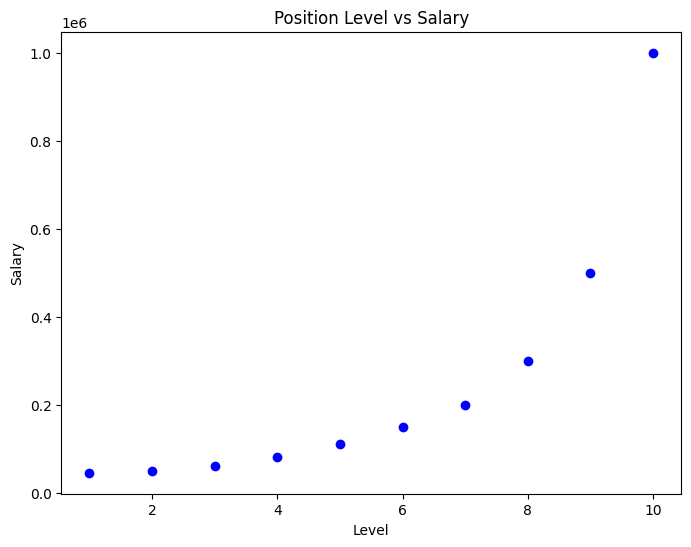

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(X, y, color='blue')

plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Position Level vs Salary")

plt.show()

/tmp/ipykernel_891/3671284813.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X.values), max(X.values), 0.1)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


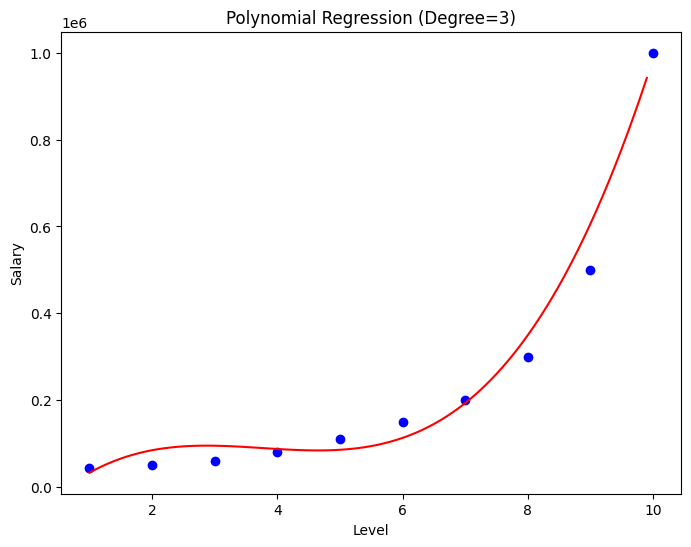

In [15]:
X_grid = np.arange(min(X.values), max(X.values), 0.1)
X_grid = X_grid.reshape(len(X_grid),1)

plt.figure(figsize=(8,6))

plt.scatter(X, y, color='blue')

plt.plot(
    X_grid,
    model.predict(poly.transform(X_grid)),
    color='red'
)

plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Polynomial Regression (Degree=3)")

plt.show()